## Введение в теорию вероятностей. Домашнее задание

###Итоги модуля 
Теория вероятностей возникла на основе анализа азартных игр. Определение закономерности исходов бросков игральных костей и вычисление шансов на выигрыш в таких играх привели учёных к интуитивному определению вероятности. Классическая формула вероятности — это отношение числа благоприятных исходов ко всем исходам. 
На уроке изучались вероятности, возникающие на примере бросания игральных кубиков и подбрасывания монетки. Также мы обсудили разницу вероятностных и статистических моделей. В конце модуля было введено понятие геометрической вероятности и рассмотрен связанный с ней метод Монте-Карло.

###Цели домашнего задания
- Закрепить полученные знания об определении вероятности.
- С помощью ряда статистических экспериментов лучше осознать разницу между вероятностной и статистической картиной мира.
- Ближе познакомиться с поведением случайных величин на практике, применив метод Монте-Карло.

###Что нужно сделать
В домашнем задании предлагается воспользоваться Jupyter Notebook для проведения наглядных статистических экспериментов. Это задачи на анализ подбрасывания монетки, бросания двух игральных кубиков и подсчёта площадей методом Монте-Карло. 
Нужно запустить готовый код, дописать его там, где требуется, посмотреть, как работает эксперимент и как зависят его результаты от различных факторов. В каждой задаче также предлагается ответить на несколько вопросов и аргументировать свой ответ.

### Что оценивается
Умение построить взаимосвязь между теоретическими вероятностями и статистическими экспериментами. В каждой задаче требуется поэкспериментировать с разными значениями параметров функций и ответить на вопросы. Задача считается выполненной, если выполнены все её условия, а также даны аргументированные ответы на вопросы.
Во втором задании также требуется дописать программу.

### Как отправить задание на проверку
Выполните задания, сохраните изменения при помощи опции Save and Checkpoint на вкладке меню File или кнопки Save and Checkpoint на панели инструментов. Отправьте итоговый файл Jupyter Notebook (в формате .ipynb) или ссылку на него через форму на платформе.

Кроме того, задания содержат несколько вопросов. Напишите ответы на эти вопросы сразу в форме. Постарайтесь аргументировать ваш ответ.


### Импорт библиотек

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

###**Задание 1.** 
Функция `coinToss` позволяет смоделировать процесс подбрасывания монетки любое количество раз. Это число задаётся параметром `number`. В результате функция выводит число испытаний и доли орлов и решек в последнем эксперименте, а также рисует график, на котором представлена суммарная доля выпавших орлов ко всем испытаниям с увеличением номера `n` от 1 до `number`.

1. Поэкспериментируйте и запустите функцию на разных значениях number. Проанализируйте поведение графика. Какими свойствами обладает кривая? 

2. К чему стремится доля орлов при увеличении числа испытаний? Как можно это объяснить?


In [2]:
def coinToss(number):
    recordList, proportionList, orli, reshki = [], [], 0, 0
    rangeList = range(1, number+1) #количество бросков
    for i in rangeList: 
        flip = random.randint(0, 1) #возвращает либо 0 (орёл), либо 1 (решка)
        if flip == 0:
            recordList.append("О")
            orli += 1
        else:
            recordList.append("Р")
            reshki += 1
        proportionList.append(orli/i)
    
    print("Число испытаний: "+ str(number))
    print("Доля орлов: " + str(orli/i) + " Доля решек: " + str(reshki/i))
    
    #Построение графика
    plt.figure(figsize=(40, 10), dpi=80)
    plt.plot(rangeList, proportionList)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.xticks(np.arange(1, number+4, step=5))
    plt.yticks(np.arange(0, 1.1, step=0.1))

Число испытаний: 5
Доля орлов: 0.4 Доля решек: 0.6


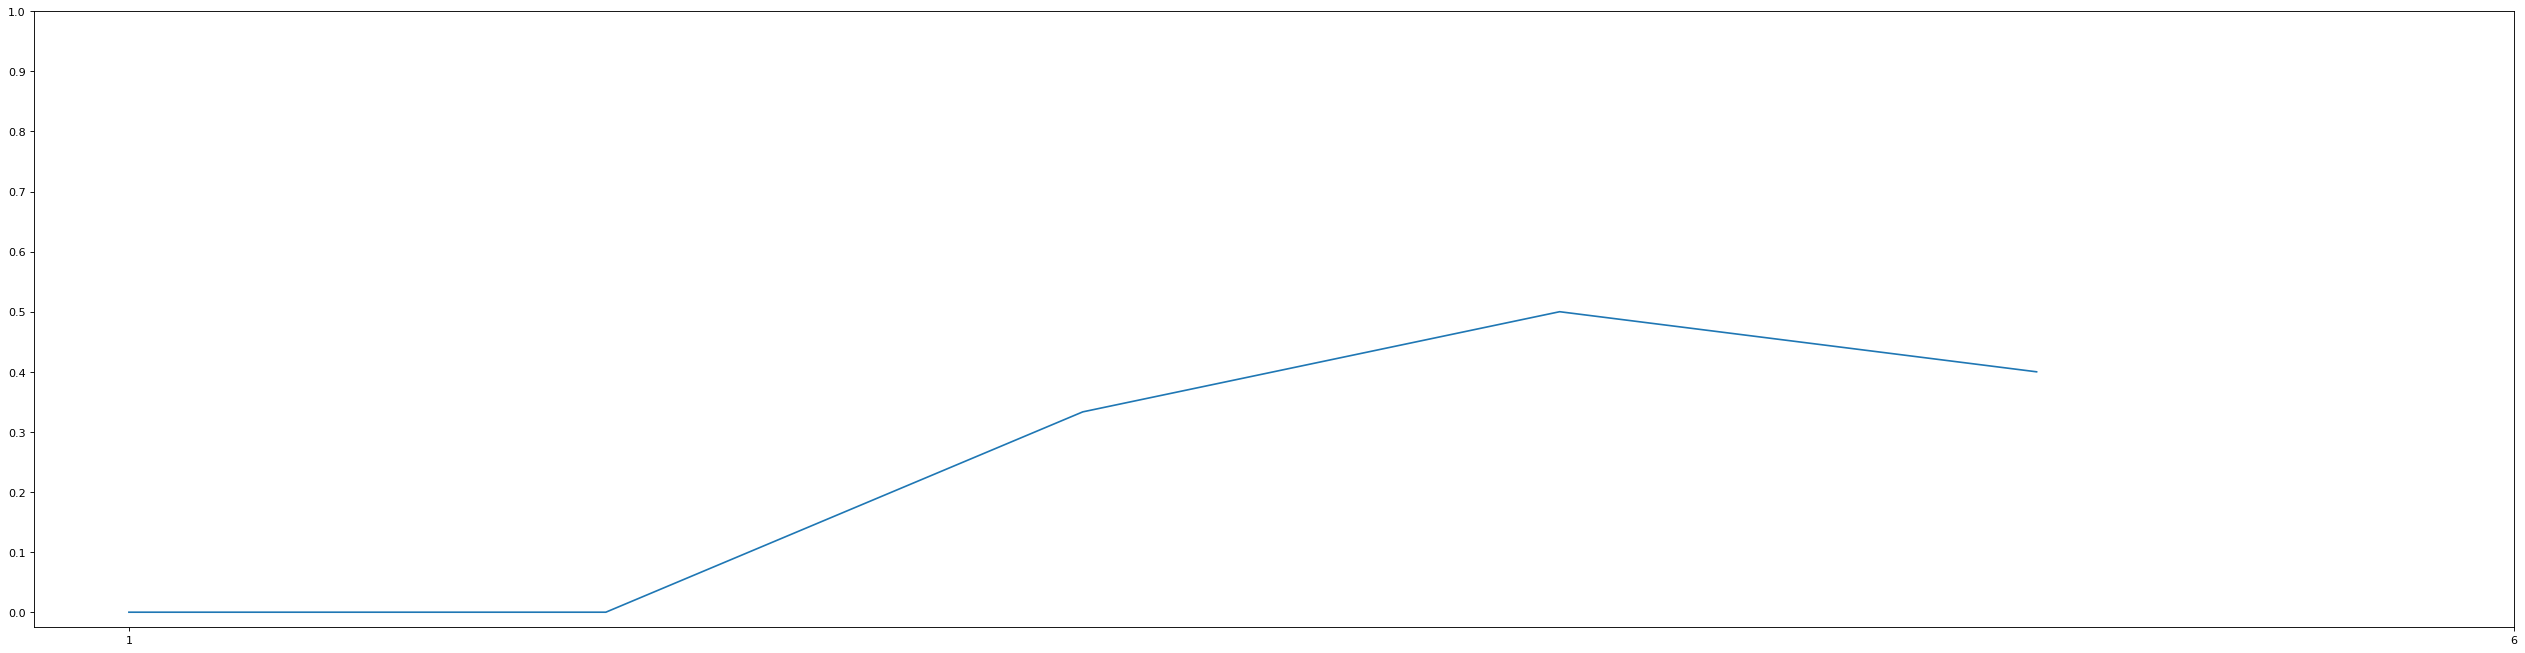

In [3]:
coinToss(5)

Число испытаний: 10
Доля орлов: 0.5 Доля решек: 0.5


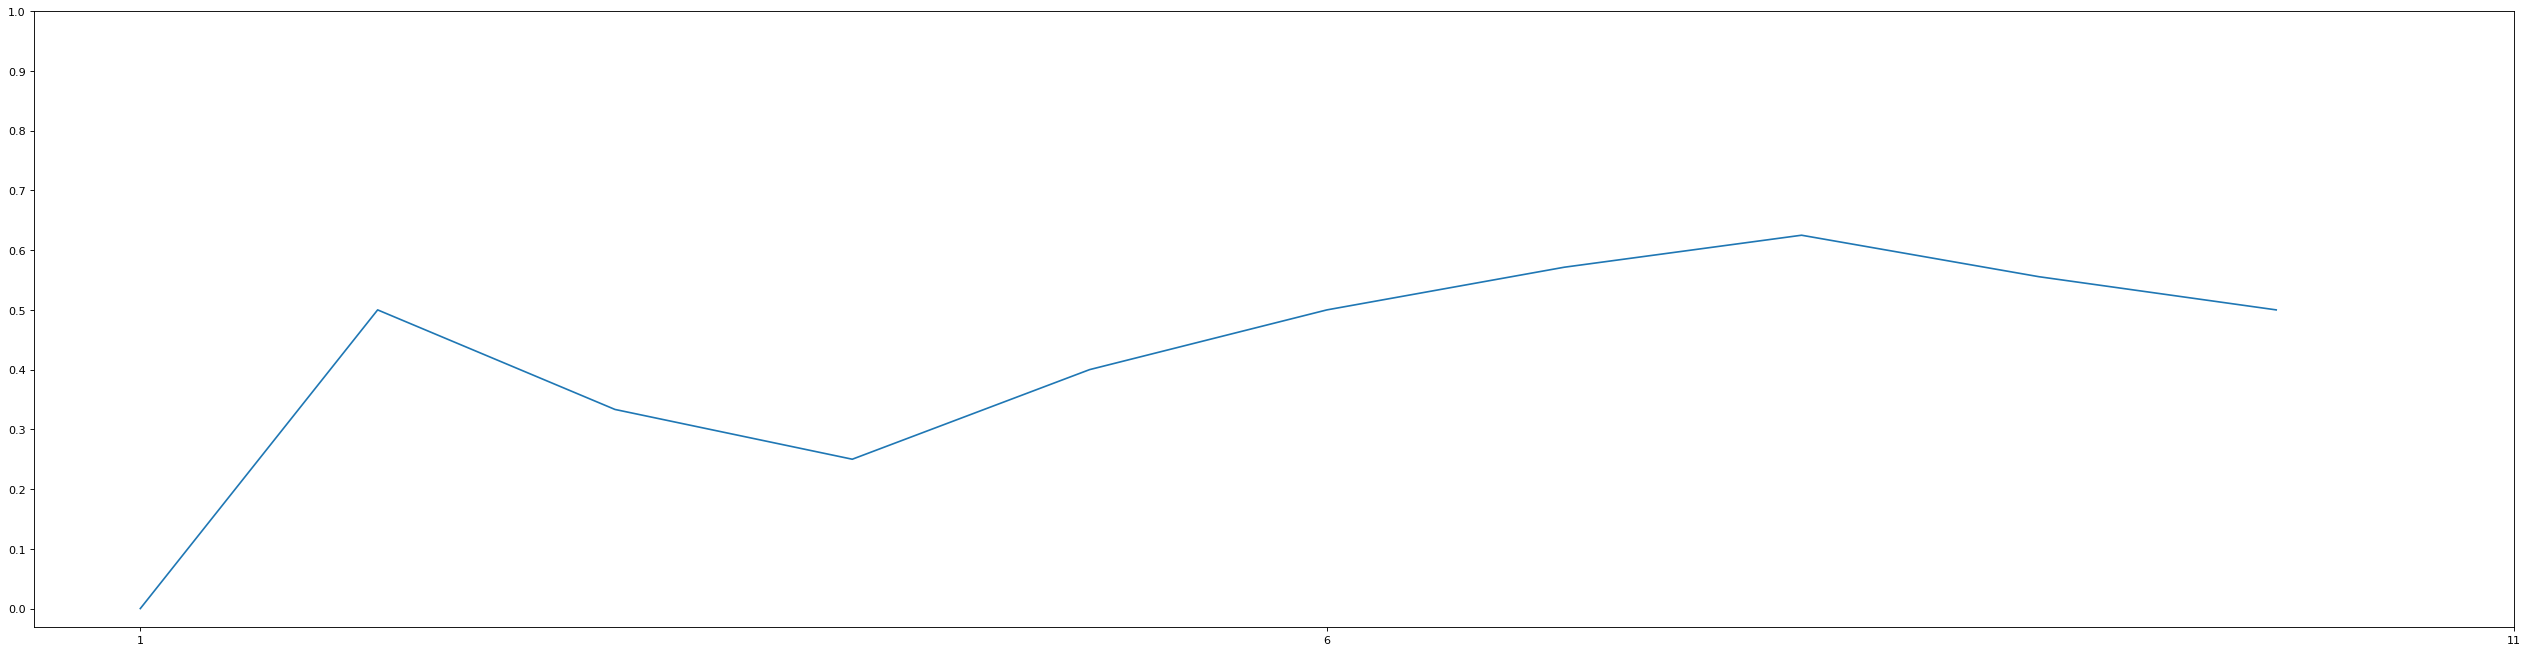

In [4]:
coinToss(10)

Число испытаний: 100
Доля орлов: 0.49 Доля решек: 0.51


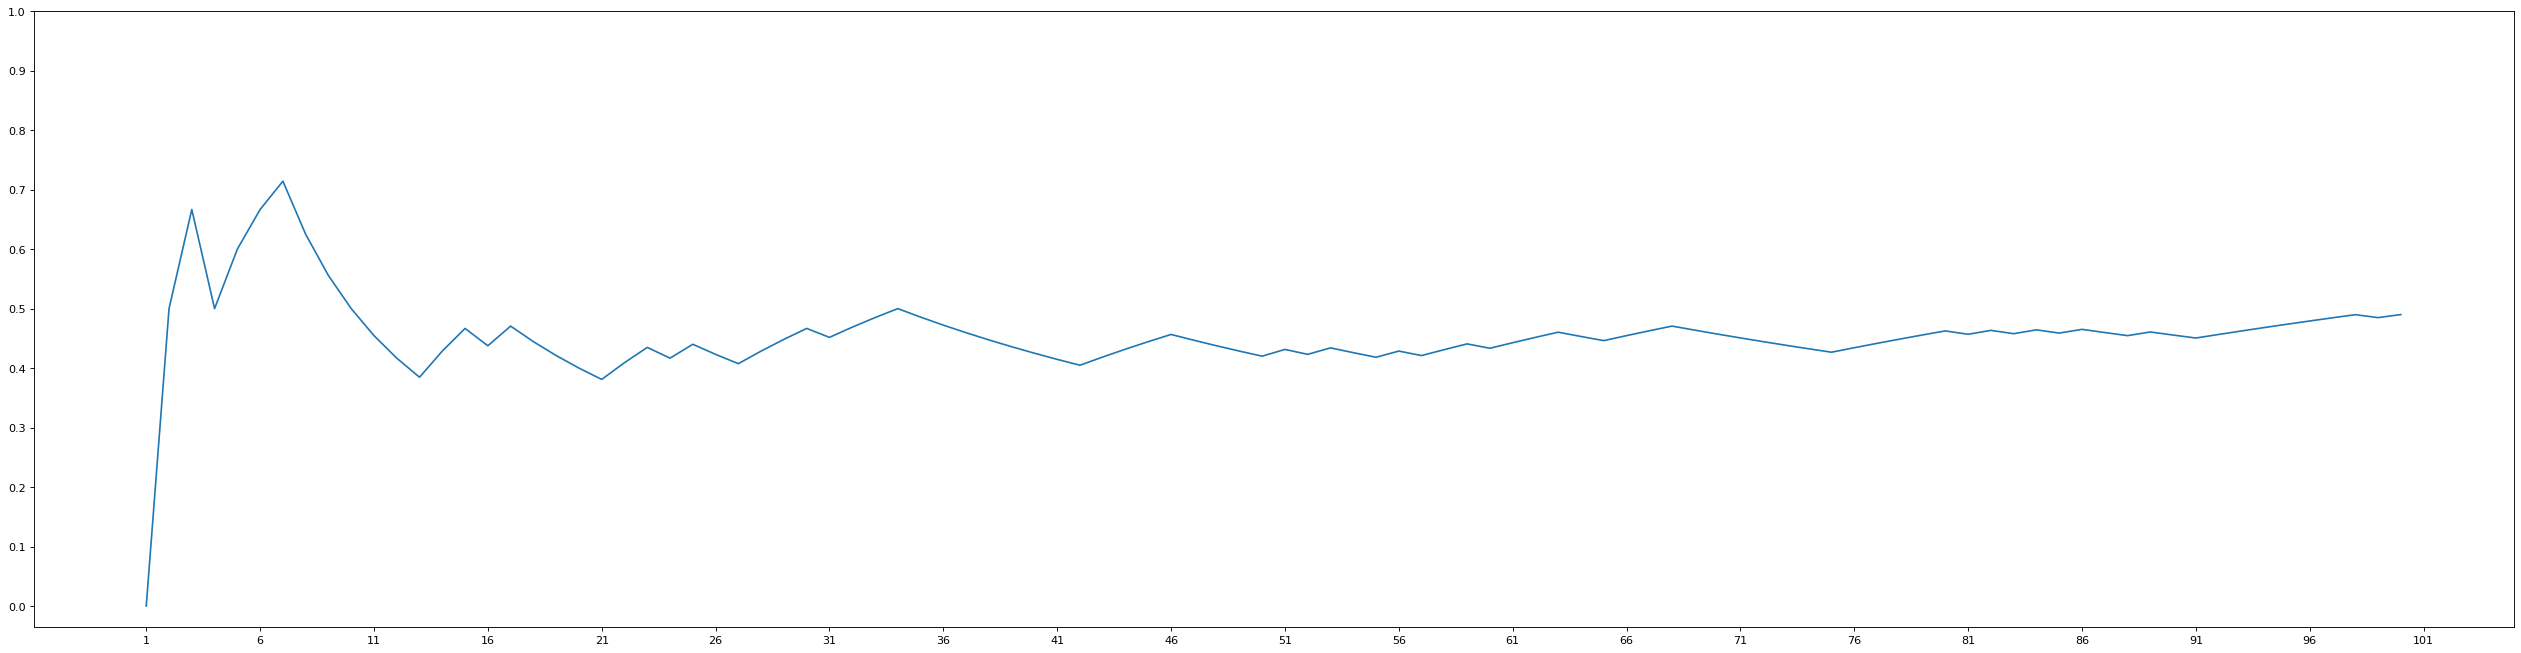

In [5]:
coinToss(100)

# С увеличением количества испытаний график частоты выпадения орла сглаживается и приближается к прямой линии.

# Наблюдается прямая зависимость между числом испытаний и стабильностью результата. Доли орлов и решек в долгосрочной перспективе стремятся к 50%, что подтверждает закон больших чисел.

###**Задание 2.** 
Функция `diceLoss` моделирует бросок двух игральных кубиков некоторое количество раз (`number`). В результате выводится вероятность того, что сумма на кубиках будет больше параметра функции `k` (считается доля выпадений, на которых сумма превысит `k`, относительно всех сумм).

1. Поэкспериментируйте с разными `number` и `k`. К каким значениям будет стремиться вероятность при фиксированном `k` и больши́х `number`? Что будет, если брать `k` = 6, 8? Как полученные вероятности будут связаны с теоретическими вероятностями?

2. К чему будет стремиться общая сумма бросков, поделённая на их количество? К чему стремится средняя разность текущего броска и полученного среднего значения? Напишите код на Python на основе исходной функции и объясните результат.


In [6]:
def diceToss(number, k):
    sumList,recordList= [], [] 
    rangeList = range(1, number+1)

    for i in rangeList: 
        flip1 = random.randint(1,6) #возвращает число от 1 до 6
        flip2 = random.randint(1,6)
        flipsum = flip1 + flip2
        sumList.append(flipsum)
        recordList.append([flip1, flip2])
    
    print('Вероятность, что сумма на кубиках превысит ' +str(k) +' при ' + str(number) + 
          ' испытаниях: ' + str(sum([x > k for x in sumList])/number))

In [7]:
l = [1, 10, 20, 50, 100, 500, 1000, 10000, 1000000]

In [8]:
for i in l:
    diceToss(i, 6)

Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
Вероятность, что сумма на кубиках превысит 6 при 10 испытаниях: 0.4
Вероятность, что сумма на кубиках превысит 6 при 20 испытаниях: 0.5
Вероятность, что сумма на кубиках превысит 6 при 50 испытаниях: 0.56
Вероятность, что сумма на кубиках превысит 6 при 100 испытаниях: 0.6
Вероятность, что сумма на кубиках превысит 6 при 500 испытаниях: 0.6
Вероятность, что сумма на кубиках превысит 6 при 1000 испытаниях: 0.586
Вероятность, что сумма на кубиках превысит 6 при 10000 испытаниях: 0.5816
Вероятность, что сумма на кубиках превысит 6 при 1000000 испытаниях: 0.583549


In [9]:
for i in l:
    diceToss(i, 8)

Вероятность, что сумма на кубиках превысит 8 при 1 испытаниях: 1.0
Вероятность, что сумма на кубиках превысит 8 при 10 испытаниях: 0.1
Вероятность, что сумма на кубиках превысит 8 при 20 испытаниях: 0.1
Вероятность, что сумма на кубиках превысит 8 при 50 испытаниях: 0.34
Вероятность, что сумма на кубиках превысит 8 при 100 испытаниях: 0.29
Вероятность, что сумма на кубиках превысит 8 при 500 испытаниях: 0.296
Вероятность, что сумма на кубиках превысит 8 при 1000 испытаниях: 0.299
Вероятность, что сумма на кубиках превысит 8 при 10000 испытаниях: 0.2762
Вероятность, что сумма на кубиках превысит 8 при 1000000 испытаниях: 0.278108


# При фиксированном k и увеличении кол-ва испытаний вероятность будет идти к 58% примерно.
# Для k=8 статистика гораздо ниже - меньше примерно в два раза 
# Это также подтверждает теорию больших чисел. При большом кол-ве повторений средний результат стремиться к ожидаемому
# Немного цифр: 
# для k=6 -теоритическая вероятность 21/36, где 21-благоприятные исходы(при которых сумма кубиков > 6), 36 общее количество исходов
# для k=8 -теоритическая вероятность 10/36, что почти в 2 РАЗА МЕНЬШЕ ЧТО ПОДТВЕРЖДАЕТ ТО ЧТО Я НАПИСАЛ РАНЕЕ ! - точнее закон больших чисел работает

побалуемся (гемблинг):

In [10]:
for i in range(1, 11):
    print(i)
    diceToss(1, 6)

1
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 0.0
2
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
3
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
4
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
5
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 0.0
6
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
7
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
8
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
9
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0
10
Вероятность, что сумма на кубиках превысит 6 при 1 испытаниях: 1.0


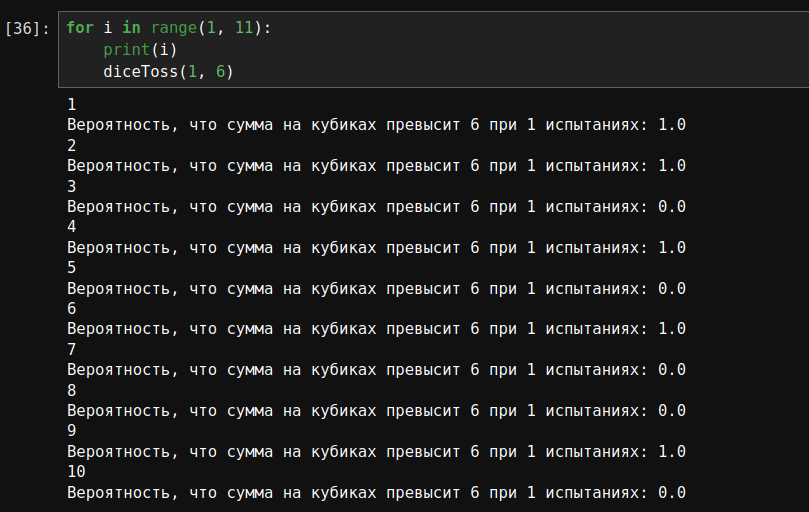

# Как видим в некоторых экспериментах(3,5,7,8,10) вероятность была равна 0 или же - ставка не зашла
# Поэтому при маленькой выбоке результат будет не самый правдивый. Человек который поставил всё на красное может и выиграет один раз, но в долгосрочной перспективе не имеет никаких гарантий на успех -> снова возращаемся к закону больших чисел

Вопрос:

К чему будет стремиться общая сумма бросков, поделённая на их количество?

In [11]:
import random
import time

In [12]:

def gambling_analysis(n=1_000_000, checkpoints=[1, 10, 100, 1000, 10000, 100000, 1000000]):

    total = 0
    
    for i in range(1, n+1):
        # бросаем кубики
        x = random.randint(1, 6) + random.randint(1, 6)
        total += x
        
        if i in checkpoints:
            mean = total / i
            diff = mean - x
            print(f"{i:7d}: среднее={mean:.6f}, тек.бросок={x:2d}, разность={diff:+.6f}")

In [13]:
gambling_analysis()

      1: среднее=7.000000, тек.бросок= 7, разность=+0.000000
     10: среднее=6.500000, тек.бросок= 7, разность=-0.500000
    100: среднее=6.880000, тек.бросок= 4, разность=+2.880000
   1000: среднее=7.068000, тек.бросок= 6, разность=+1.068000
  10000: среднее=7.041000, тек.бросок= 7, разность=+0.041000
 100000: среднее=6.997960, тек.бросок=11, разность=-4.002040
1000000: среднее=6.999490, тек.бросок= 6, разность=+0.999490


# Как видим, при увеличении числа испытаний выборочное среднее суммы двух кубиков стремится к теоретическому математическому ожиданию, равному 7. Уже после 10 000 бросков ошибка составляет менее 0.5%, а после миллиона сходится практически идеально

# Это чистая работа закона больших чисел: чем больше испытаний, тем ближе среднее к теоретическому матожиданию (7)

Вопрос:

К чему стремится средняя разность текущего броска и полученного среднего значения?

In [15]:
# честно говоря вообще не понял о чем ворос, но попробую посчитать 

def gambling_analysis(n=1_000_000, checkpoints=[1, 10, 100, 1000, 10000, 100000, 1000000]):

    total = 0
    
    for i in range(1, n+1):
        # бросаем кубики
        x = random.randint(1, 6) + random.randint(1, 6)
        total += x
        
        if i in checkpoints:
            mean = total / i
            diff = mean - x
            print(f"{i:7d}: среднее={mean:.6f}, тек.бросок={x:2d}, разность={diff:+.6f}")


In [16]:
gambling_analysis()


      1: среднее=9.000000, тек.бросок= 9, разность=+0.000000
     10: среднее=6.700000, тек.бросок= 4, разность=+2.700000
    100: среднее=6.810000, тек.бросок=10, разность=-3.190000
   1000: среднее=6.872000, тек.бросок= 4, разность=+2.872000
  10000: среднее=6.999700, тек.бросок= 5, разность=+1.999700
 100000: среднее=6.994400, тек.бросок= 7, разность=-0.005600
1000000: среднее=7.000098, тек.бросок= 9, разность=-1.999902


# Полученный результат нам ни о чем не говорит, возможно задача интепретирована неправильно

In [17]:
# представим что в задаче просилось найти отклонение текущего среднего от теоретического матожидания

def gambling_correct(n=1_000_000, checkpoints=[1, 10, 100, 1000, 10000, 100000, 1000000]):
    total = 0
    
    for i in range(1, n+1):
        x = random.randint(1,6) + random.randint(1,6)
        total += x
        
        if i in checkpoints:
            mean = total / i
            error = mean - 7  
            print(f"{i:7d}: среднее={mean:.6f}, отклонение от 7={error:+.6f}")


In [18]:
gambling_correct()

      1: среднее=6.000000, отклонение от 7=-1.000000
     10: среднее=7.500000, отклонение от 7=+0.500000
    100: среднее=7.150000, отклонение от 7=+0.150000
   1000: среднее=6.905000, отклонение от 7=-0.095000
  10000: среднее=6.990800, отклонение от 7=-0.009200
 100000: среднее=7.003680, отклонение от 7=+0.003680
1000000: среднее=7.000137, отклонение от 7=+0.000137


# Как видим отклонение(средняя ошибка) зависит от теоритического матожидания и падает при увеличении кол-ва итераций, что снова подтверждает закон больших чисел

###**Задание 3.**
 
Как было рассказано в уроке, метод Монте-Карло — это серия численных методов, позволяющих моделировать случайные процессы для изучения некоторого явления. Один из способов применения метода Монте-Карло заключается в измерении различных площадей. Если рассмотреть географическую карту и случайным образом равномерно разбросать на ней точки с произвольными координатами, то окажется, что количество точек в определённом регионе будет пропорционально площади этого региона. Следующая задача как раз на эту тему. 

Ниже представлен код, который делает следующее. На отрезке от −1 до 1 берутся два значения, `x` и `y`, из которых строится точка на плоскости с координатами (x, y). Если такая точка попадает внутрь единичного круга с центром в нуле, то такая точка отмечается синим цветом, в противном случае — красным. Количество точек задаётся параметром `n`.

Вызовите функцию для разных `n`. К чему будет стремиться доля синих точек? Как это связано с площадями геометрических фигур? Проанализируйте, как меняется доля синих точек с ростом количества точек, и сравните её с теоретическим значением площади.


In [70]:
import numpy as np
import matplotlib.pyplot as plt

In [71]:
# сделаем более красивую и правильную в отличии данной

def plot_circle(n):
    n = int(n)
    x = 2 * np.random.random(n) - 1
    y = 2 * np.random.random(n) - 1
    
    inside = x*x + y*y <= 1
    insideX, insideY = x[inside], y[inside]
    outsideX, outsideY = x[~inside], y[~inside]
    
    print(f'Точек внутри круга: {len(insideX)}')
    print(f'Точек снаружи круга: {len(outsideX)}')
    print(f'Доля точек внутри: {len(insideX)/n:.6f}')
    
    pi_est = 4 * len(insideX) / n
    print(f'Оценка π: {pi_est:.6f}')
    
    
    # Рисуем точки
    fig, ax = plt.subplots()
    ax.scatter(insideX, insideY, c='b', alpha=0.6, edgecolor=None, label='Внутри')
    ax.scatter(outsideX, outsideY, c='r', alpha=0.7, edgecolor=None, label='Снаружи')
    
    # Рисуем границу круга
    circle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=2)
    ax.add_patch(circle)
    
    ax.set_aspect('equal')
    ax.set_title(f'Метод Монте-Карло (n={n})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend()
    plt.show()

Точек внутри круга: 16
Точек снаружи круга: 9
Доля точек внутри: 0.640000
Оценка π: 2.560000


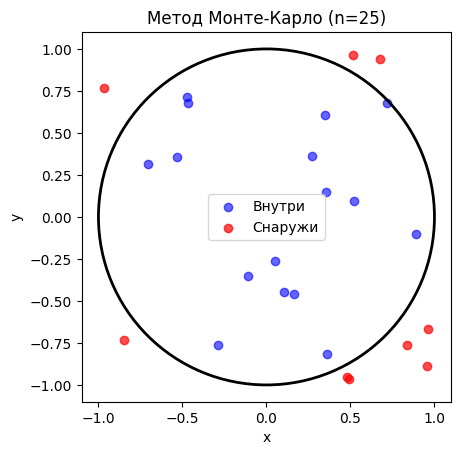

In [72]:
plot_circle(25);

Точек внутри круга: 79
Точек снаружи круга: 21
Доля точек внутри: 0.790000
Оценка π: 3.160000


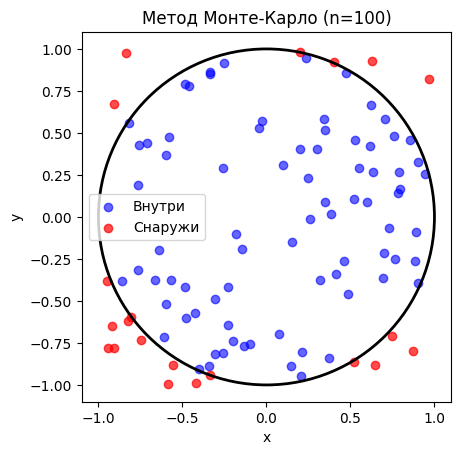

In [73]:
plot_circle(100);

Точек внутри круга: 395
Точек снаружи круга: 105
Доля точек внутри: 0.790000
Оценка π: 3.160000


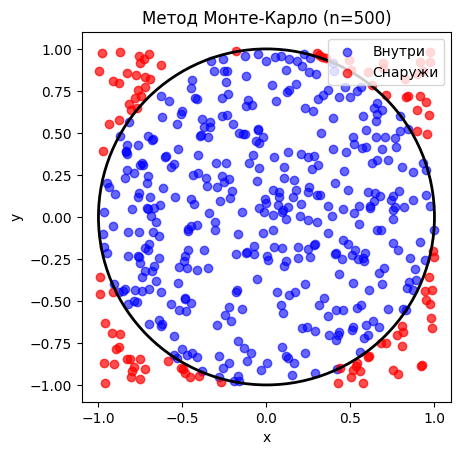

In [74]:
plot_circle(500);

Точек внутри круга: 796
Точек снаружи круга: 204
Доля точек внутри: 0.796000
Оценка π: 3.184000


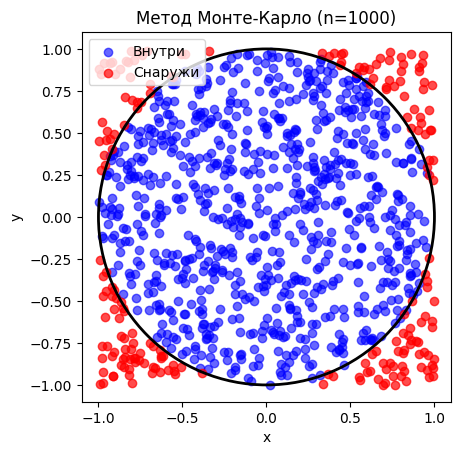

In [75]:
plot_circle(1000);

Вопросы:
1) К чему будет стремиться доля синих точек?
2) Как это связано с площадями геометрических фигур?
3) Проанализируйте, как меняется доля синих точек с ростом количества точек, и сравните её с теоретическим значением площади.


Ответы: 
1) Доля синих точек будет стремиться к увеличению 
2) метод папы Карло 
3) При малом количестве точек доля может сильно колебаться, но с увеличением числа точек она стабилизируется и стремится к теоретическому значению. Чем больше точек, тем точнее оценка

# Вывод по всей работе:
# Закон больших чисел играет огромную роль в теории вероятности, на большой дистанции средний результат стремится к матожиданию. По мере прохождения этой практики я доказал это на реальных примерах. Метод Монте-Карло вызвал сложности в понимании, поэтому основное внимание в работе было уделено закону больших чисел и его проверке на практике